# Homework 8: Denoising Autoencoder for Sine Curves
**ASTR 5900 — Computational Physics & Astrophysics**  
**Sidhartha Samtani | University of Oklahoma**

In [1]:
import subprocess, sys
try:
    import torch
except ImportError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'torch',
                           '--index-url', 'https://download.pytorch.org/whl/cpu', '-q'])
    import torch
print('PyTorch', torch.__version__)

PyTorch 2.11.0


In [2]:
import warnings, time
warnings.filterwarnings('ignore')
import numpy as np
import matplotlib.pyplot as plt
import torch, torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

np.random.seed(42)
torch.manual_seed(42)
DEVICE = torch.device('cpu')
print('Device:', DEVICE)

Device: cpu


## Q1. Data Generation

In [3]:
N = 100
n_curves = 10000
t = np.linspace(0, 4*np.pi, N)

A_all     = np.random.uniform(0.5, 1.5,     n_curves)
omega_all = np.random.uniform(0.5, 2.0,     n_curves)
phi_all   = np.random.uniform(0,   2*np.pi, n_curves)

clean_curves = A_all[:,None] * np.sin(omega_all[:,None]*t[None,:] + phi_all[:,None])
sigma        = 0.2
noisy_curves = clean_curves + np.random.normal(0, sigma, clean_curves.shape)

print('clean_curves:', clean_curves.shape, ' noisy_curves:', noisy_curves.shape)

clean_curves: (10000, 100)  noisy_curves: (10000, 100)


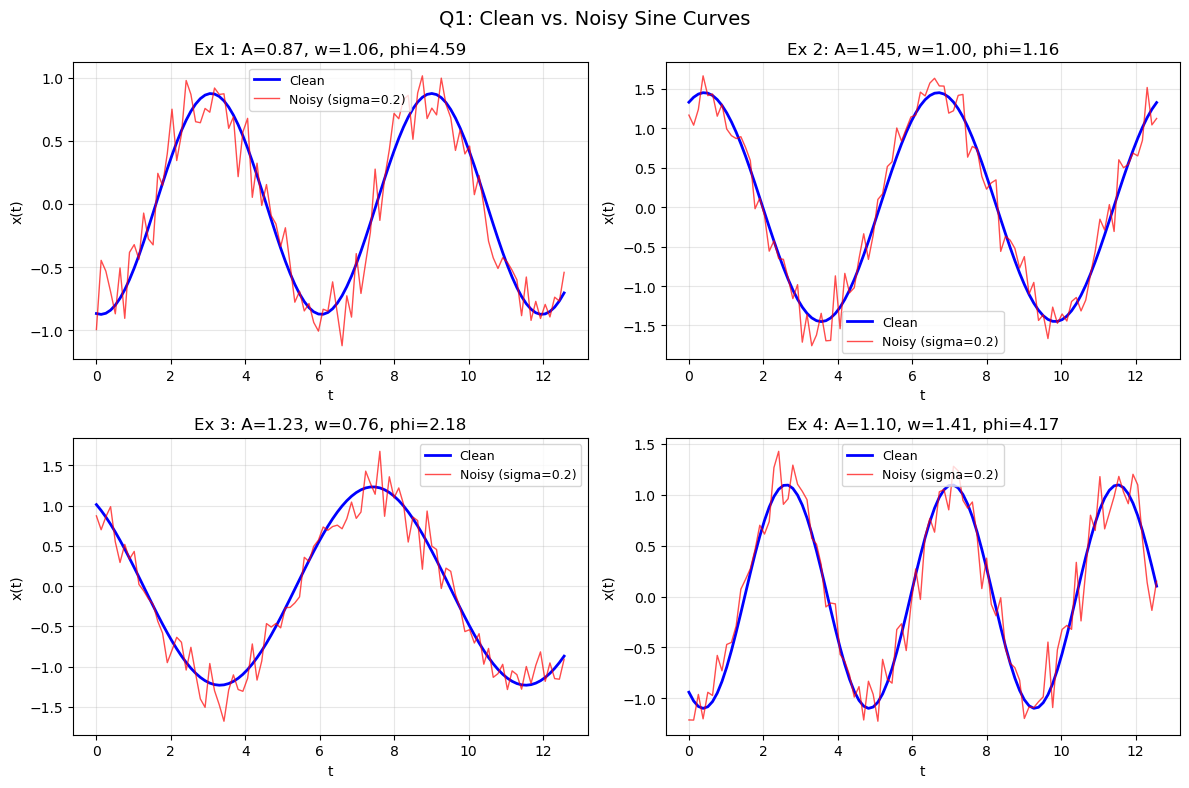

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for i, ax in enumerate(axes.flat):
    ax.plot(t, clean_curves[i], 'b-', lw=2, label='Clean')
    ax.plot(t, noisy_curves[i], 'r-', lw=1, alpha=0.7, label='Noisy (sigma=0.2)')
    ax.set_xlabel('t'); ax.set_ylabel('x(t)')
    ax.set_title(f'Ex {i+1}: A={A_all[i]:.2f}, w={omega_all[i]:.2f}, phi={phi_all[i]:.2f}')
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
plt.suptitle('Q1: Clean vs. Noisy Sine Curves', fontsize=14)
plt.tight_layout()
plt.savefig('Q1_clean_vs_noisy.png', dpi=150, bbox_inches='tight')
plt.show()

In [5]:
split_90   = int(0.9 * n_curves)
X_train_90 = noisy_curves[:split_90];  Y_train_90 = clean_curves[:split_90]
X_val_90   = noisy_curves[split_90:];  Y_val_90   = clean_curves[split_90:]
print(f'Train: {X_train_90.shape}  |  Val: {X_val_90.shape}')

Train: (9000, 100)  |  Val: (1000, 100)


## Helper Functions

In [6]:
def build_autoencoder(layer_sizes):
    layers = []
    for i in range(len(layer_sizes) - 1):
        layers.append(nn.Linear(layer_sizes[i], layer_sizes[i+1]))
        if i < len(layer_sizes) - 2:
            layers.append(nn.ReLU())
    return nn.Sequential(*layers).to(DEVICE)

def train_model(model, X_tr, Y_tr, X_v, Y_v, epochs=50, batch_size=128, lr=1e-3):
    opt     = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()
    Xt = torch.tensor(X_tr, dtype=torch.float32)
    Yt = torch.tensor(Y_tr, dtype=torch.float32)
    Xv = torch.tensor(X_v,  dtype=torch.float32)
    Yv = torch.tensor(Y_v,  dtype=torch.float32)
    loader = DataLoader(TensorDataset(Xt, Yt), batch_size=batch_size, shuffle=True)
    train_losses, val_losses = [], []
    for _ in range(epochs):
        model.train()
        ep_loss = 0.0
        for xb, yb in loader:
            opt.zero_grad(); loss = loss_fn(model(xb), yb)
            loss.backward(); opt.step()
            ep_loss += loss.item() * len(xb)
        train_losses.append(ep_loss / len(Xt))
        model.eval()
        with torch.no_grad():
            val_losses.append(loss_fn(model(Xv), Yv).item())
    return train_losses, val_losses

def predict(model, X):
    model.eval()
    with torch.no_grad():
        return model(torch.tensor(X, dtype=torch.float32)).numpy()

print('Helpers ready.')

Helpers ready.


## Q2. Autoencoder Model  (100 → 64 → 16 → 64 → 100)

In [7]:
ae_q2 = build_autoencoder([100, 64, 16, 64, 100])
print(ae_q2)
print(f'Parameters: {sum(p.numel() for p in ae_q2.parameters()):,}')

Sequential(
  (0): Linear(in_features=100, out_features=64, bias=True)
  (1): ReLU()
  (2): Linear(in_features=64, out_features=16, bias=True)
  (3): ReLU()
  (4): Linear(in_features=16, out_features=64, bias=True)
  (5): ReLU()
  (6): Linear(in_features=64, out_features=100, bias=True)
)
Parameters: 15,092


In [8]:
train_loss_q2, val_loss_q2 = train_model(
    ae_q2, X_train_90, Y_train_90, X_val_90, Y_val_90, epochs=50)
print(f'Final train MSE: {train_loss_q2[-1]:.6f}')
print(f'Final val   MSE: {val_loss_q2[-1]:.6f}')

Final train MSE: 0.003487
Final val   MSE: 0.004092


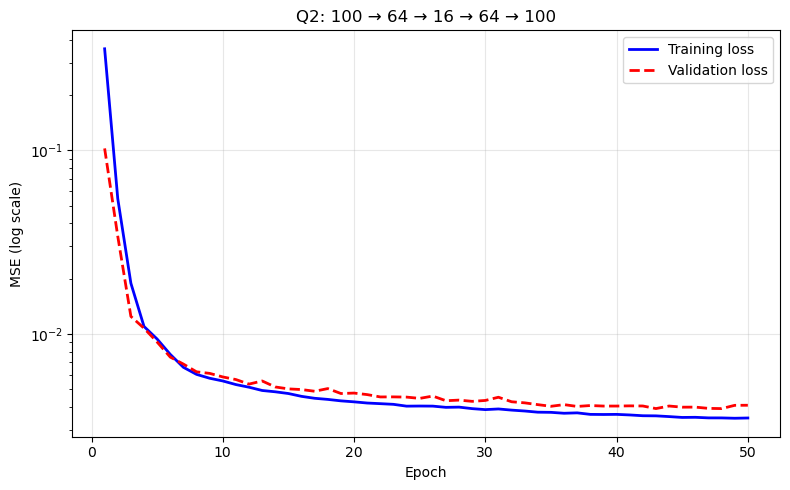

In [9]:
# One plot — both train and val together
fig, ax = plt.subplots(figsize=(8, 5))
ax.semilogy(range(1,51), train_loss_q2, 'b-',  lw=2, label='Training loss')
ax.semilogy(range(1,51), val_loss_q2,   'r--', lw=2, label='Validation loss')
ax.set_xlabel('Epoch'); ax.set_ylabel('MSE (log scale)')
ax.set_title('Q2: 100 → 64 → 16 → 64 → 100')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('Q2_loss_curves.png', dpi=150, bbox_inches='tight')
plt.show()

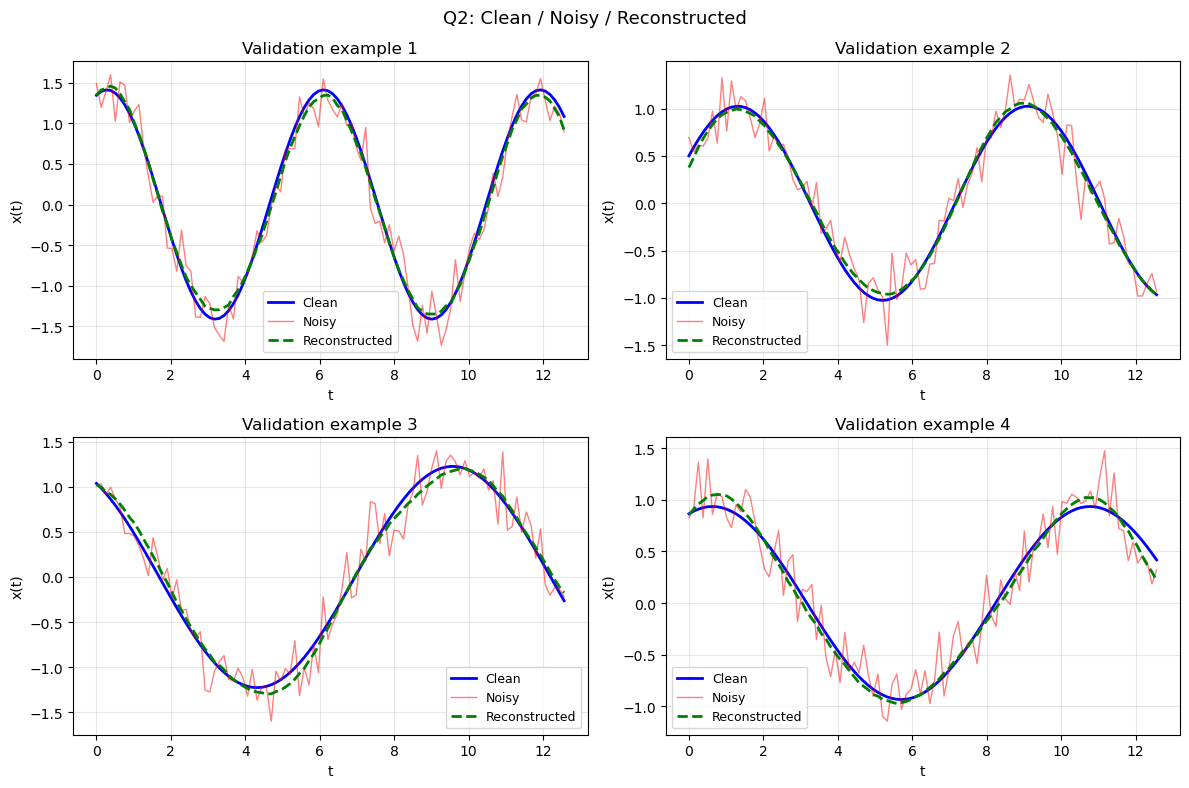

In [10]:
recon_q2 = predict(ae_q2, X_val_90[:4])
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for i, ax in enumerate(axes.flat):
    ax.plot(t, Y_val_90[i], 'b-',  lw=2,            label='Clean')
    ax.plot(t, X_val_90[i], 'r-',  lw=1, alpha=0.5, label='Noisy')
    ax.plot(t, recon_q2[i], 'g--', lw=2,            label='Reconstructed')
    ax.set_xlabel('t'); ax.set_ylabel('x(t)')
    ax.set_title(f'Validation example {i+1}')
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
plt.suptitle('Q2: Clean / Noisy / Reconstructed', fontsize=13)
plt.tight_layout()
plt.savefig('Q2_reconstructions.png', dpi=150, bbox_inches='tight')
plt.show()

## Q3(a): Training Data Size

One plot per split — each shows training and validation loss together.

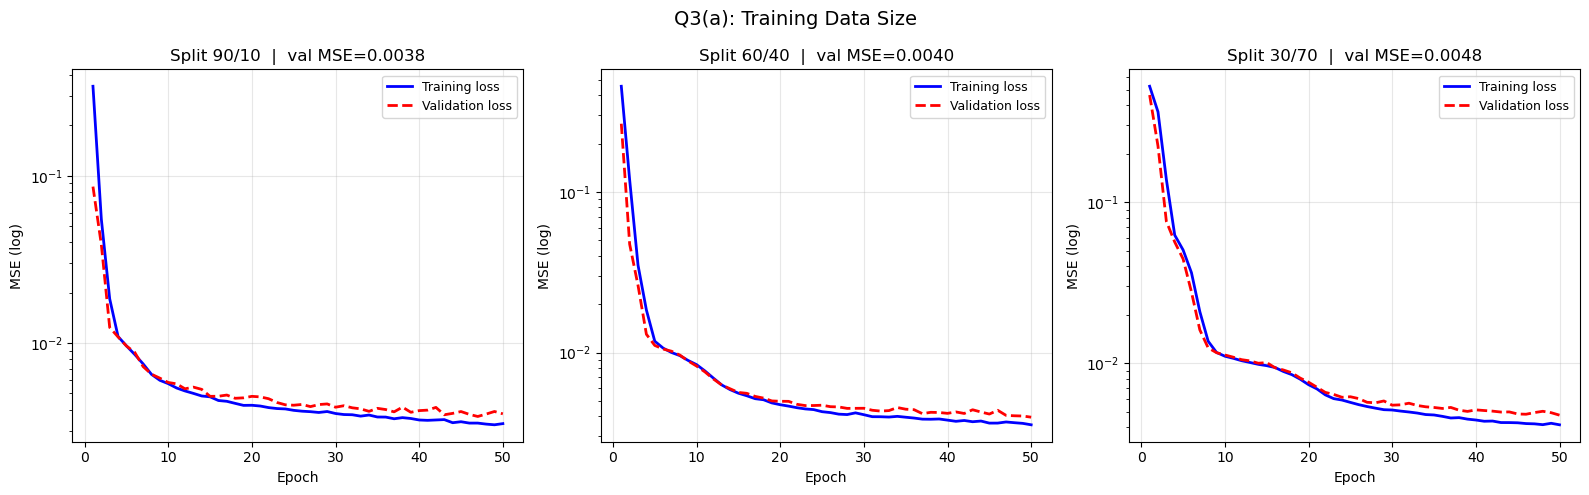

  90/10: val MSE = 0.003777
  60/40: val MSE = 0.003956
  30/70: val MSE = 0.004770


In [11]:
splits = {'90/10': 0.9, '60/40': 0.6, '30/70': 0.3}
val_mse_by_split = {}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (label, frac) in zip(axes, splits.items()):
    s = int(frac * n_curves)
    trl, vll = train_model(
        build_autoencoder([100, 64, 16, 64, 100]),
        noisy_curves[:s], clean_curves[:s],
        noisy_curves[s:], clean_curves[s:], epochs=50)
    val_mse_by_split[label] = vll[-1]
    ax.semilogy(range(1,51), trl, 'b-',  lw=2, label='Training loss')
    ax.semilogy(range(1,51), vll, 'r--', lw=2, label='Validation loss')
    ax.set_title(f'Split {label}  |  val MSE={vll[-1]:.4f}')
    ax.set_xlabel('Epoch'); ax.set_ylabel('MSE (log)')
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

plt.suptitle('Q3(a): Training Data Size', fontsize=14)
plt.tight_layout()
plt.savefig('Q3a_data_size.png', dpi=150, bbox_inches='tight')
plt.show()

for k, v in val_mse_by_split.items():
    print(f'  {k}: val MSE = {v:.6f}')

## Q3(b): Network Architecture  (bottleneck = 4)

One plot per architecture — each shows training and validation loss together.

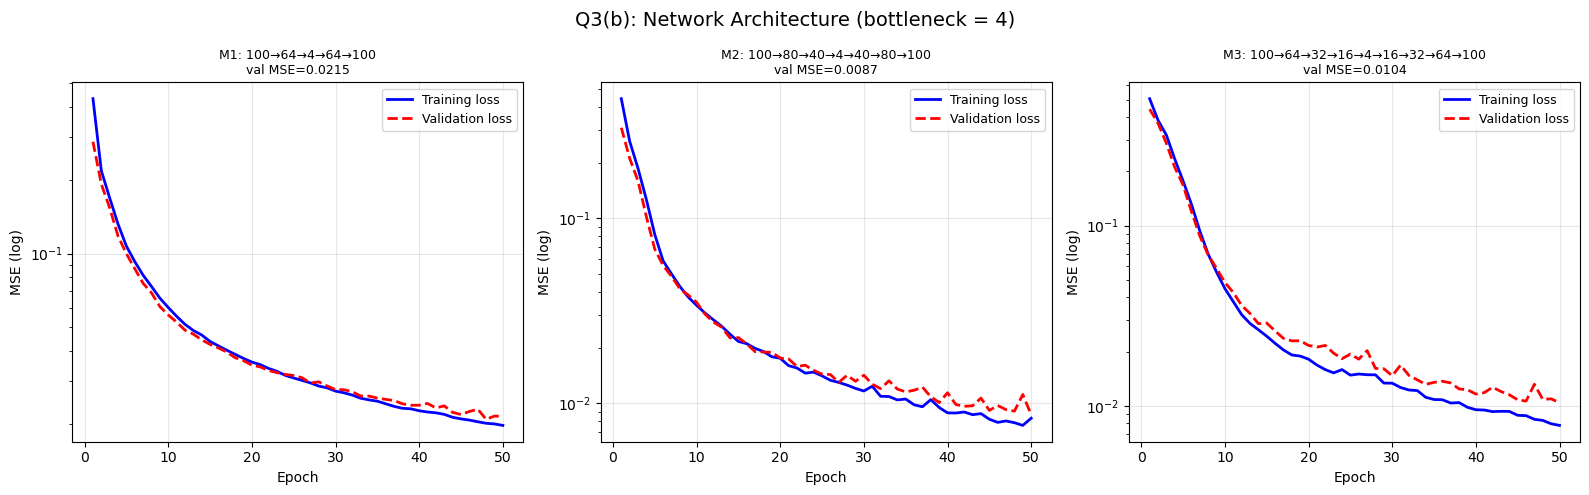

  M1: 100→64→4→64→100: val MSE=0.021478, time=1.7s
  M2: 100→80→40→4→40→80→100: val MSE=0.008688, time=2.0s
  M3: 100→64→32→16→4→16→32→64→100: val MSE=0.010422, time=2.0s


In [12]:
arch_configs = {
    'M1: 100→64→4→64→100':                  [100, 64, 4, 64, 100],
    'M2: 100→80→40→4→40→80→100':            [100, 80, 40, 4, 40, 80, 100],
    'M3: 100→64→32→16→4→16→32→64→100':      [100, 64, 32, 16, 4, 16, 32, 64, 100],
}
arch_results = {}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (label, layers) in zip(axes, arch_configs.items()):
    t0 = time.time()
    trl, vll = train_model(build_autoencoder(layers),
                           X_train_90, Y_train_90, X_val_90, Y_val_90, epochs=50)
    arch_results[label] = {'val_mse': vll[-1], 'time': time.time()-t0}
    ax.semilogy(range(1,51), trl, 'b-',  lw=2, label='Training loss')
    ax.semilogy(range(1,51), vll, 'r--', lw=2, label='Validation loss')
    ax.set_title(f'{label}\nval MSE={vll[-1]:.4f}', fontsize=9)
    ax.set_xlabel('Epoch'); ax.set_ylabel('MSE (log)')
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

plt.suptitle('Q3(b): Network Architecture (bottleneck = 4)', fontsize=14)
plt.tight_layout()
plt.savefig('Q3b_architectures.png', dpi=150, bbox_inches='tight')
plt.show()

for k, v in arch_results.items():
    print(f'  {k}: val MSE={v["val_mse"]:.6f}, time={v["time"]:.1f}s')

## Q3(c): Bottleneck Size

One plot per bottleneck size — each shows training and validation loss together.

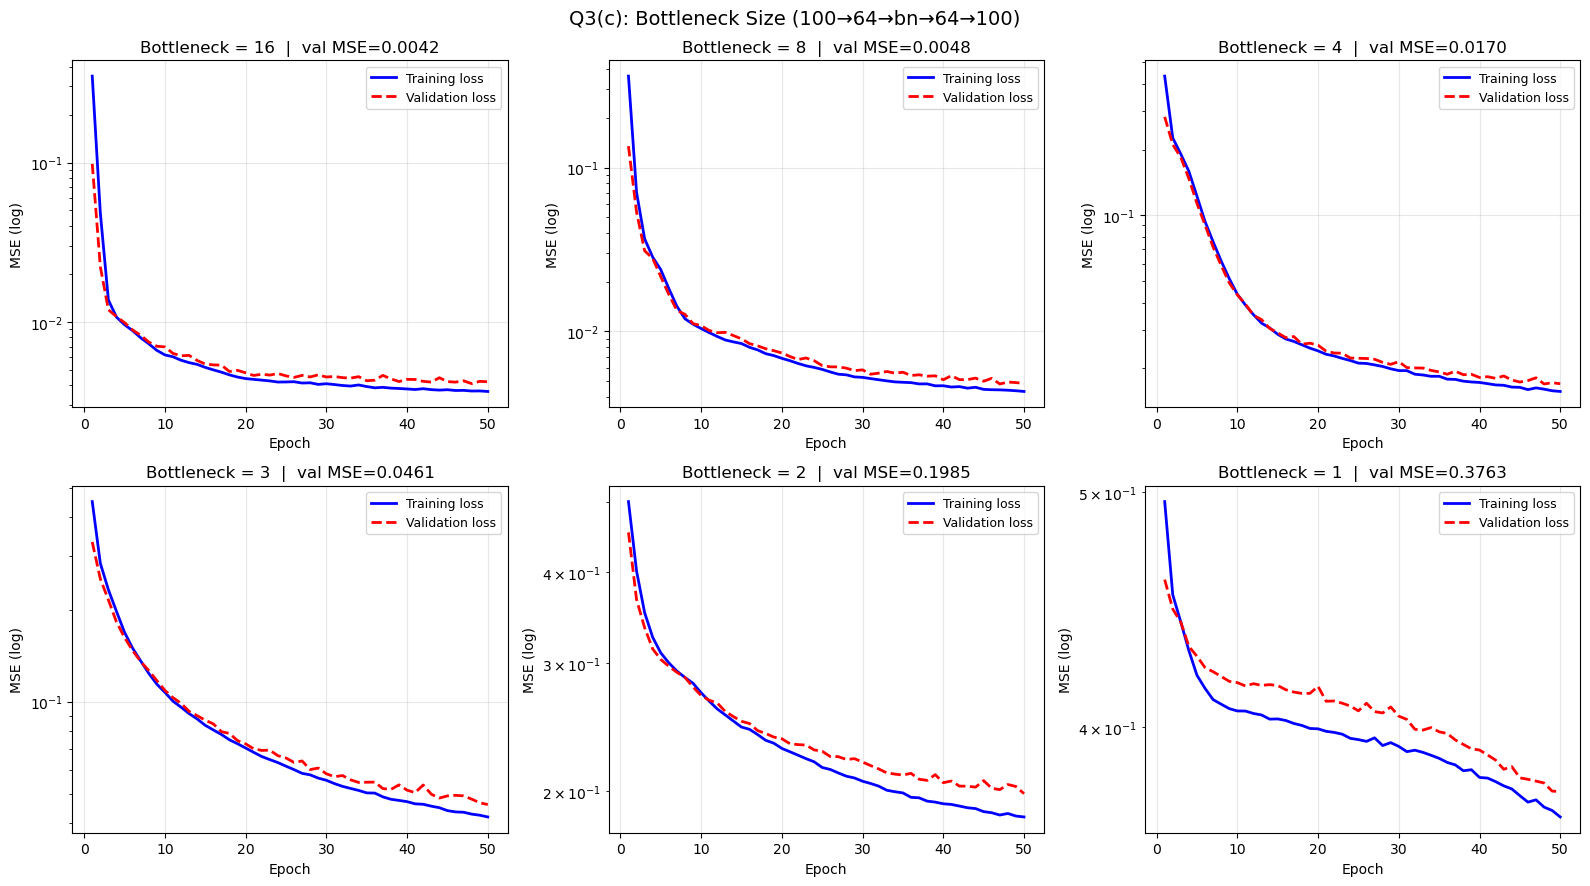

  bn=16: val MSE=0.004214
  bn=8: val MSE=0.004817
  bn=4: val MSE=0.017035
  bn=3: val MSE=0.046097
  bn=2: val MSE=0.198523
  bn=1: val MSE=0.376309


In [13]:
bottlenecks = [16, 8, 4, 3, 2, 1]
bn_results  = {}

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

for ax, bn in zip(axes.flat, bottlenecks):
    trl, vll = train_model(build_autoencoder([100, 64, bn, 64, 100]),
                           X_train_90, Y_train_90, X_val_90, Y_val_90, epochs=50)
    bn_results[bn] = vll[-1]
    ax.semilogy(range(1,51), trl, 'b-',  lw=2, label='Training loss')
    ax.semilogy(range(1,51), vll, 'r--', lw=2, label='Validation loss')
    ax.set_title(f'Bottleneck = {bn}  |  val MSE={vll[-1]:.4f}')
    ax.set_xlabel('Epoch'); ax.set_ylabel('MSE (log)')
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

plt.suptitle('Q3(c): Bottleneck Size (100→64→bn→64→100)', fontsize=14)
plt.tight_layout()
plt.savefig('Q3c_bottleneck.png', dpi=150, bbox_inches='tight')
plt.show()

for bn, v in bn_results.items():
    print(f'  bn={bn}: val MSE={v:.6f}')

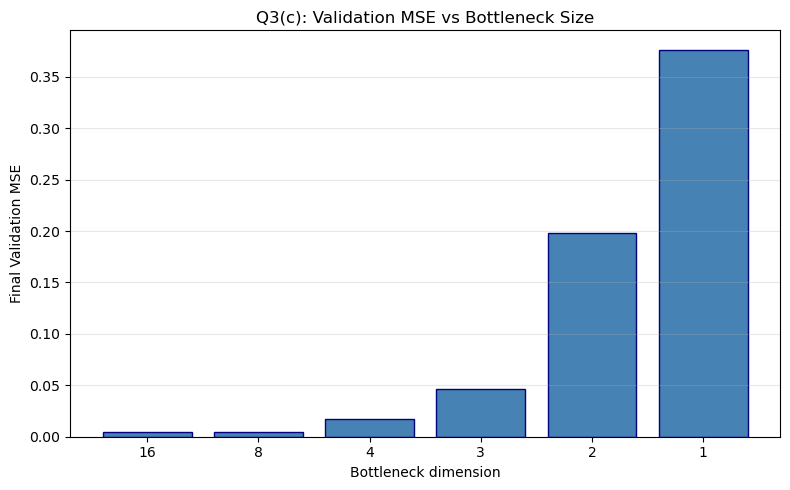

In [14]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar([str(b) for b in bottlenecks], [bn_results[b] for b in bottlenecks],
       color='steelblue', edgecolor='navy')
ax.set_xlabel('Bottleneck dimension'); ax.set_ylabel('Final Validation MSE')
ax.set_title('Q3(c): Validation MSE vs Bottleneck Size')
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('Q3c_bottleneck_bar.png', dpi=150, bbox_inches='tight')
plt.show()

## Q3(d): Noise Models — Laplace vs Gaussian

One plot per noise model — each shows training and validation loss together.

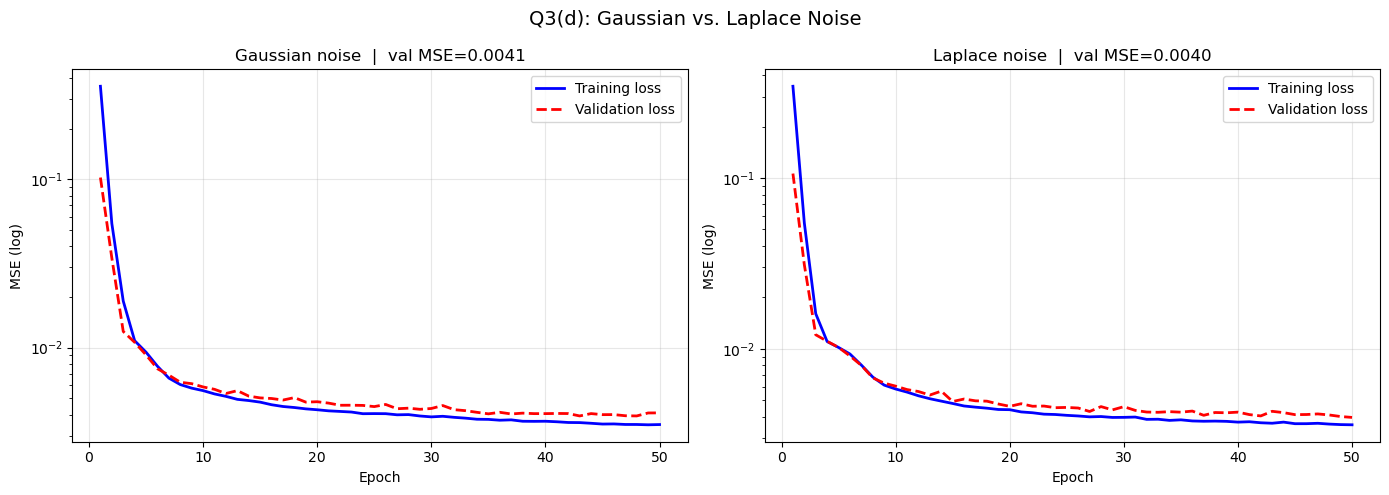

Gaussian val MSE: 0.004092
Laplace  val MSE: 0.003959


In [15]:
noisy_laplace = clean_curves + np.random.laplace(0, sigma/np.sqrt(2), clean_curves.shape)

ae_lap = build_autoencoder([100, 64, 16, 64, 100])
trl_lap, vll_lap = train_model(ae_lap,
                               noisy_laplace[:split_90], clean_curves[:split_90],
                               noisy_laplace[split_90:], clean_curves[split_90:], epochs=50)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gaussian
axes[0].semilogy(range(1,51), train_loss_q2, 'b-',  lw=2, label='Training loss')
axes[0].semilogy(range(1,51), val_loss_q2,   'r--', lw=2, label='Validation loss')
axes[0].set_title(f'Gaussian noise  |  val MSE={val_loss_q2[-1]:.4f}')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('MSE (log)')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Laplace
axes[1].semilogy(range(1,51), trl_lap, 'b-',  lw=2, label='Training loss')
axes[1].semilogy(range(1,51), vll_lap, 'r--', lw=2, label='Validation loss')
axes[1].set_title(f'Laplace noise  |  val MSE={vll_lap[-1]:.4f}')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('MSE (log)')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.suptitle('Q3(d): Gaussian vs. Laplace Noise', fontsize=14)
plt.tight_layout()
plt.savefig('Q3d_laplace_loss.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Gaussian val MSE: {val_loss_q2[-1]:.6f}')
print(f'Laplace  val MSE: {vll_lap[-1]:.6f}')

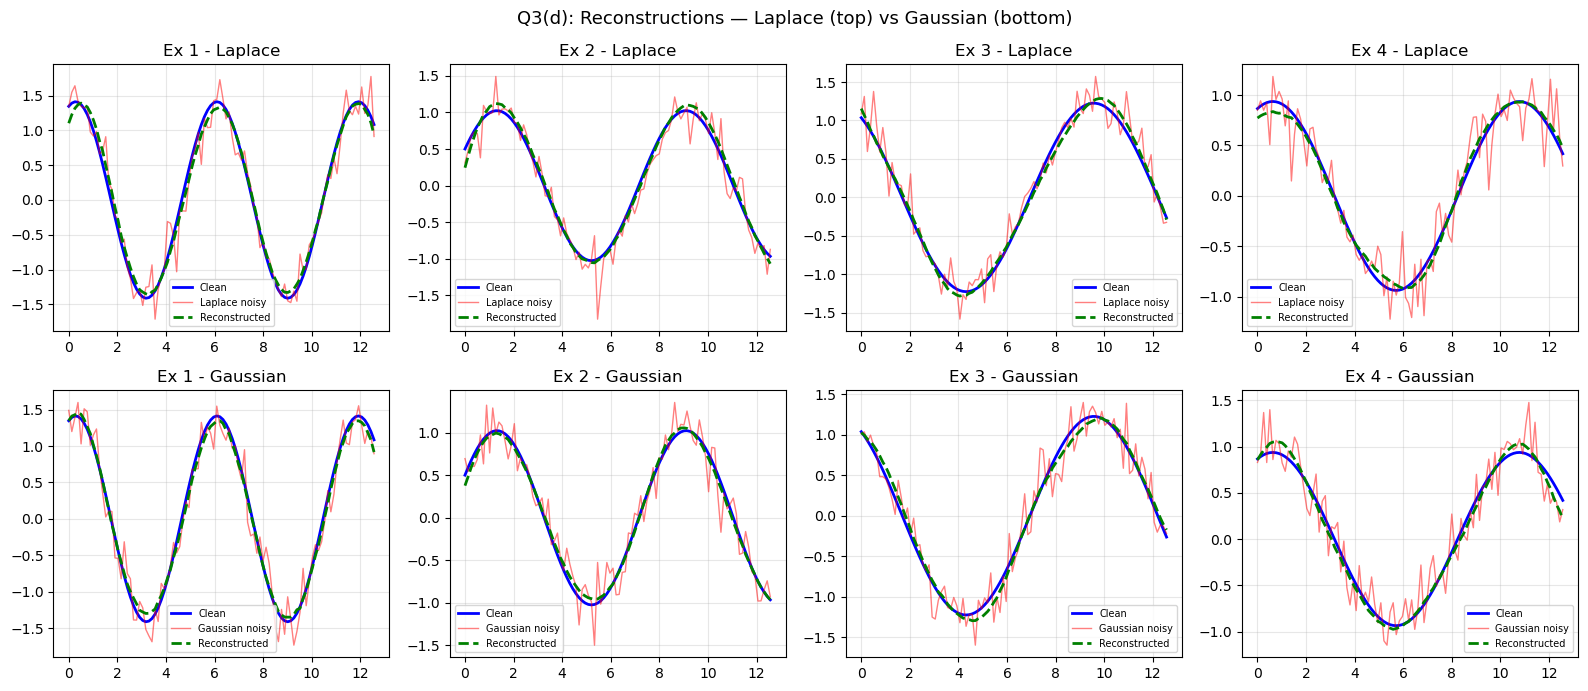

In [16]:
XL_val = noisy_laplace[split_90:]; YL_val = clean_curves[split_90:]
recon_lap = predict(ae_lap, XL_val[:4])
recon_gau = predict(ae_q2,  X_val_90[:4])

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for i in range(4):
    for row, (xn, yn, rc, lbl) in enumerate([
        (XL_val[i],  YL_val[i],  recon_lap[i], 'Laplace noisy'),
        (X_val_90[i],Y_val_90[i],recon_gau[i], 'Gaussian noisy')
    ]):
        axes[row,i].plot(t, yn, 'b-',  lw=2,          label='Clean')
        axes[row,i].plot(t, xn, 'r-',  lw=1, alpha=.5, label=lbl)
        axes[row,i].plot(t, rc, 'g--', lw=2,           label='Reconstructed')
        axes[row,i].set_title(f'Ex {i+1} - {"Laplace" if row==0 else "Gaussian"}')
        axes[row,i].legend(fontsize=7); axes[row,i].grid(True, alpha=0.3)
plt.suptitle('Q3(d): Reconstructions — Laplace (top) vs Gaussian (bottom)', fontsize=13)
plt.tight_layout()
plt.savefig('Q3d_laplace_recon.png', dpi=150, bbox_inches='tight')
plt.show()

## Results Summary

In [17]:
print('='*55)
print('RESULTS SUMMARY')
print('='*55)
print(f'Q2  baseline (100->64->16->64->100): val MSE = {val_loss_q2[-1]:.6f}')
print('\nQ3(a) training size:')
for k, v in val_mse_by_split.items():
    print(f'  {k}: {v:.6f}')
print('\nQ3(b) architectures (bottleneck=4):')
for k, v in arch_results.items():
    print(f'  {k}: val MSE={v["val_mse"]:.6f}, time={v["time"]:.1f}s')
print('\nQ3(c) bottleneck size:')
for bn, v in bn_results.items():
    print(f'  bn={bn}: val MSE={v:.6f}')
print(f'\nQ3(d) Gaussian={val_loss_q2[-1]:.6f}  Laplace={vll_lap[-1]:.6f}')

RESULTS SUMMARY
Q2  baseline (100->64->16->64->100): val MSE = 0.004092

Q3(a) training size:
  90/10: 0.003777
  60/40: 0.003956
  30/70: 0.004770

Q3(b) architectures (bottleneck=4):
  M1: 100→64→4→64→100: val MSE=0.021478, time=1.7s
  M2: 100→80→40→4→40→80→100: val MSE=0.008688, time=2.0s
  M3: 100→64→32→16→4→16→32→64→100: val MSE=0.010422, time=2.0s

Q3(c) bottleneck size:
  bn=16: val MSE=0.004214
  bn=8: val MSE=0.004817
  bn=4: val MSE=0.017035
  bn=3: val MSE=0.046097
  bn=2: val MSE=0.198523
  bn=1: val MSE=0.376309

Q3(d) Gaussian=0.004092  Laplace=0.003959
